# Import thư viện

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Import dữ liệu

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

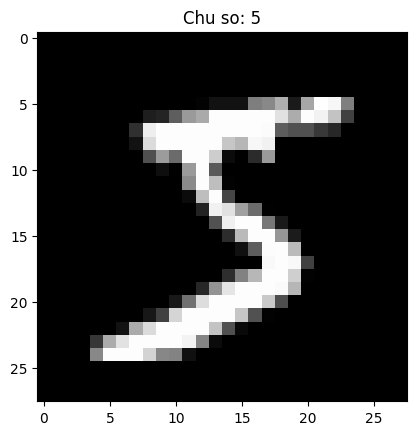

In [ ]:
# xem thu hinh anh tap du lieu
import matplotlib.pyplot as plt
from PIL import Image

ind_data = 28
img = Image.fromarray(X_train[ind_data])
plt.imshow(img, cmap="gray")
plt.title("Chu so: " + str(y_train[ind_data]))
plt.show()

# Chuẩn hóa dữ liệu

In [6]:
# Scale từ mã màu 0 -> 255 [0, ...., 1]
X_train = X_train.astype("float64") / 255.0
X_test = X_test.astype("float64") / 255.0

X_train.shape, X_test.shape


((60000, 28, 28), (10000, 28, 28))

**Tham số cần lưu ý:**
- 'n' : số hình (60000)
- 'w' : chiều rộng (28)
- 'h' : chiều cao (28)
- 'd' : direction (vì hình trắng đen nên chọn **d = 1**, hình có màu rgb thì **d = 3**)
- 'class' : số lớp (kết quả bao gồm các lớp với % khác nhau: [0: 1, 1:00.0, ...])

In [ ]:
# Thêm chiều d
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_train.shape, X_test.shape

In [7]:
# Thêm class
my_classes = 10 # 0 -> 9
y_train = keras.utils.to_categorical(y_train, my_classes)
y_test = keras.utils.to_categorical(y_test, my_classes)
y_train.shape, y_test.shape

((60000, 10), (10000, 10))

# Huấn luyện mô hình

In [9]:
# Khai bao mo hinh
input_shape = [28, 28, 1]
model = keras.Sequential([
    keras.layers.Conv2D(32, kernel_size=(3, 3), input_shape=input_shape),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(64, kernel_size=(3, 3)),    # tung do phuc tap cho mo hinh
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(), # Chuyen mo hinhf 2D -> 1D
    keras.layers.Dense(my_classes, activation="softmax"), # lop output
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Hoc
batch_size = 128 # số lượng ảnh mẫu được xử lý mỗi lần mô hình cập nhật trọng số
epochs = 10 # số lần toàn bộ tập dữ liệu được đưa vào mô hình để học
validation_split = 0.2 # phần trăm dữ liệu được sử dụng để đánh giá mô hình trong quá trình học
model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9138 - loss: 0.3090 - val_accuracy: 0.9670 - val_loss: 0.1141
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9746 - loss: 0.0877 - val_accuracy: 0.9783 - val_loss: 0.0720
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9805 - loss: 0.0642 - val_accuracy: 0.9813 - val_loss: 0.0625
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9836 - loss: 0.0528 - val_accuracy: 0.9834 - val_loss: 0.0596
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9860 - loss: 0.0451 - val_accuracy: 0.9831 - val_loss: 0.0575
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9879 - loss: 0.0397 - val_accuracy: 0.9820 - val_loss: 0.0608
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9818 - val_loss: 0.0581
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9896 - loss: 0.0317 - 

# Đánh giá mô hình

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Độ chính xác trên tập kiểm tra: {accuracy:.4f}") # học được bao nhiều phần trăm từ dữ liệu
print(f"Độ mất mát trên tập kiểm tra: {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9851 - loss: 0.0500
Độ chính xác trên tập kiểm tra: 0.9851
Độ mất mát trên tập kiểm tra: 0.0500


# Dự đoán mô hình

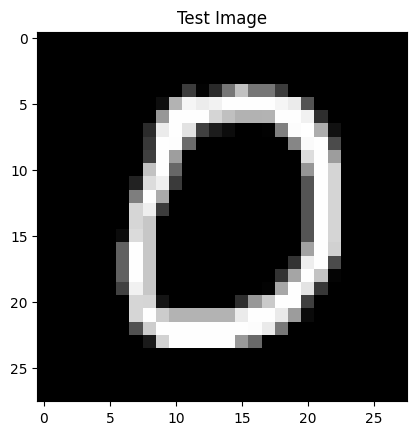

In [13]:
test_img = X_test[10]
# VE HINH ANH TEST
img = Image.fromarray((test_img.squeeze() * 255).astype('uint8'))
plt.imshow(img, cmap='gray')
plt.title("Test Image")
plt.show()

Vì layer Dense ở cuối có 10 units nên kết quả của predict cũng trả về một numpy array có 10 giá trị, mỗi giá trị là tỉ lệ mà hình thuộc lớp tương ứng.

> Ví dụ: Mô hình phân loại 4 lớp có kết quả predict là [0.1, 0.2, 0.7, 0.0] nghĩa là hình có 10% thuộc lớp thứ nhất, 20% thuộc lớp thứ hai, 70% thuộc lớp thứ ba và 0% thuộc lớp cuối cùng.

> Lưu ý: Tổng tất cả các tỉ lệ của mảng kết quả luôn bằng 1, tương ứng với 100%.

In [14]:
test_img = np.expand_dims(test_img, 0)
preds = model.predict(test_img)
print(preds)
test_pred = np.argmax(preds)
print(f"Predicted class = {test_pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[9.9999964e-01 1.2150322e-15 1.9509375e-07 1.5762270e-11 3.8234958e-19
  3.0521058e-10 1.0545471e-08 2.5714875e-11 3.8281028e-10 1.1288340e-07]]
Predicted class = 0
